# Keyword spam model MVP

## Setup

You'll need to download en_core_web_sm for this task

In [1]:
# ! uv pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl

In [2]:
# import nltk

# nltk.download("punkt_tab")

In [1]:
from itertools import chain
import os
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy
import truecase
import xgboost as xgb
import unidecode

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
nlp = spacy.load("en_core_web_sm")

## Useful feature engineering functions

In [2]:
def proportion_of_stopwords(description):
    tokens = description.split(" ")
    num_stopwords = len(
        [word for word in tokens if word.lower() in nlp.Defaults.stop_words]
    )
    return float(num_stopwords) / float(len(tokens)) if len(tokens) else 0.0


def average_length_of_word(description):
    tokens = description.split(" ")
    return np.mean([len(word) for word in tokens]) if len(tokens) else 0.0


# Only if the entire word is digit will this consider the word being digit
# Ignore words where digit is part of the word e.g. y2k [Done]
def proportion_of_numbers(description):
    tokens = description.split(" ")
    num_digits = len([word for word in tokens if word.isdigit()])
    return float(num_digits) / float(len(tokens)) if len(tokens) else 0.0


def normalise_nonascii_chars(input_str):
    return unidecode.unidecode(input_str)


# This is removing hash tags. Spammy descriptions could have lots of hashtags
# Could be removing legitimate signals [Done]
def replace_special_chars(main_string):
    return re.sub("[,;@#!\?\+\*\n\-: /]", " ", main_string)


def keep_alphanumeric_chars(string_input):
    return re.sub("[^A-Za-z0-9& ]", "", string_input)


def remove_spaces(string_input):
    return " ".join(string_input.split())


def lemmatize(string_input):
    token_object = nlp(string_input)
    lemmas_list = [
        word.lemma_ if word.lemma_ != "-PRON-" else word.text for word in token_object
    ]
    return " ".join(lemmas_list)


def drop_digits(s):
    return "".join([i for i in s if not i.isdigit()])


def clean_description(input_str):
    input_str = replace_special_chars(input_str.lower())
    input_str = normalise_nonascii_chars(input_str)
    input_str = keep_alphanumeric_chars(input_str)
    input_str = lemmatize(input_str)
    input_str = remove_spaces(input_str)
    return input_str

## SK Learn Pipeline

In [3]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer


class FeatureEngineering(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.is_fitted_ = True
        return self

    def transform(self, X):
        df = X.copy()
        # Clean description
        df["description"] = df["description"].apply(clean_description)
        # Feature engineering on cleaned decription
        df["proportion_of_stopwords"] = df["description"].apply(proportion_of_stopwords)
        df["average_length_of_word"] = df["description"].apply(average_length_of_word)
        df["proportion_of_numbers"] = df["description"].apply(proportion_of_numbers)
        # Drop digits, true case, then get perform entity recognition
        df["description"] = df["description"].apply(drop_digits)
        df["description_truecase"] = df["description"].apply(truecase.get_true_case)
        df["description_nlp"] = df["description_truecase"].apply(nlp)

        df["named_entities"] = ""

        for i, description_nlp in df["description_nlp"].items():
            named_entities_sets = description_nlp.ents
            named_entities = list(set(chain(*named_entities_sets)))
            df["named_entities"].at[i] = " ".join(j.text for j in named_entities)

        return df


column_transformer = ColumnTransformer(
    transformers=[
        (
            "named_entities_tfidf",
            TfidfVectorizer(
                stop_words=list(nlp.Defaults.stop_words),
                max_features=500,
            ),
            "named_entities",
        ),
        (
            "description_tfidf",
            TfidfVectorizer(
                stop_words=list(nlp.Defaults.stop_words),
                max_features=500,
            ),
            "description",
        ),
        (
            "manual_features",
            "passthrough",
            [
                "proportion_of_stopwords",
                "average_length_of_word",
                "proportion_of_numbers",
            ],
        ),
    ],
    remainder="drop",
)


class DenseTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.is_fitted_ = True
        return self

    def transform(self, X):
        return X.toarray() if hasattr(X, "toarray") else X

In [4]:
from sklearn.pipeline import Pipeline

feature_processing_pipeline = Pipeline(
    steps=[
        ("feature_engineering", FeatureEngineering()),
        ("features", column_transformer),
        # Avoid returning a dense matrix as it would force materialisation of zeros
        # Which could cause memory explosion if we need > 500 TFIDF features
        # ("to_dense", DenseTransformer()),
    ]
)

In [5]:
cwd = os.getcwd()

df_train = pd.read_csv(os.path.join(cwd, "../data/train_set.tsv"), sep="\t")[
    ["product_id", "description", "label"]
]

df_train = df_train.reset_index(drop=True)

X_train = df_train.drop(columns=["label"]).copy()
y_train = df_train["label"].copy()

print("Transforming X_train..")
X_train = feature_processing_pipeline.fit_transform(X_train)

print("Reading test data..")
# Do not touch df_test until final eval to avoid data leakage
df_test = pd.read_csv(os.path.join(cwd, "../data/test_set.tsv"), sep="\t")[
    ["product_id", "description", "label"]
]
X_test = df_test.drop(columns=["label"]).copy()
y_test = df_test["label"].copy()

print("Transform X_test without fitting...")
X_test = feature_processing_pipeline.transform(X_test)

Transforming X_train..


/Users/shengy/Documents/GitHub/depop_takehome_task/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(


Reading test data..
Transform X_test without fitting...


# Hyperparam Tuning and Fit model

In [6]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split


# Keep X_test untouched for final evaluation.

# X_train_proper used for training the model
# X_calib is used only for model calibration.
X_train_proper, X_calib, y_train_proper, y_calib = train_test_split(
    X_train,
    y_train,
    test_size=0.3,
    stratify=y_train,
    random_state=42,
)

# X_train_tune to perform CV search and refit model on best params
# X_train_eval is used only for XGBoost early stopping.
X_train_tune, X_train_eval, y_train_tune, y_train_eval = train_test_split(
    X_train_proper,
    y_train_proper,
    test_size=0.2,
    stratify=y_train_proper,
    random_state=42,
)

# 500 trees with early stopping for 5 rounds for illustrative purpose only
# In reality we could go even higher
base_clf = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=500,
    early_stopping_rounds=5,
    tree_method="hist",
    random_state=42,
    n_jobs=1,
)

param_grid = {
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "min_child_weight": [1, 5],
    "subsample": [0.8, 1.0],
    "reg_lambda": [0.1, 1.0],
}

# Do only three fits to reduce compute time
# But in reality we want to have ~ 5 splits
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42,
)

grid_search = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid,
    scoring="f1",  # Scoring with F1 instead of accuracy
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
    error_score="raise",
)

grid_search.fit(
    X_train_tune,
    y_train_tune,
    eval_set=[(X_train_eval, y_train_eval)],
    verbose=False,
)

clf = grid_search.best_estimator_

print(f"Best CV F1: {grid_search.best_score_:.4f}")
print(f"Best params: {grid_search.best_params_}")
print(f"Best iteration: {clf.best_iteration}")

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best CV F1: 0.9263
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'reg_lambda': 0.1, 'subsample': 0.8}
Best iteration: 85


## Predict on model

In [7]:
y_train_proper_pred = clf.predict(X_train_proper)
y_test_pred = clf.predict(X_test)

## Evaluate

In [8]:
# Data set mean is 58%? Is this a realisitic expectation for distribution of spams? I'd expect spams to be less prevalent
# If training set distribution is not the same as real world distribution -> calibration of model will be off..
print(df_train["label"].mean())
print(df_test["label"].mean())

0.598
0.528


In [9]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train_proper, y_train_proper_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Train Accuracy: {(train_accuracy * 100.0):.2f}%")
print(f"Test Accuracy: {(test_accuracy * 100.0):.2f}%")

Train Accuracy: 96.95%
Test Accuracy: 96.60%


F1 score: 0.9681050656660413
Recall: 0.9772727272727273
Precision: 0.9591078066914498
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       236
           1       0.96      0.98      0.97       264

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500



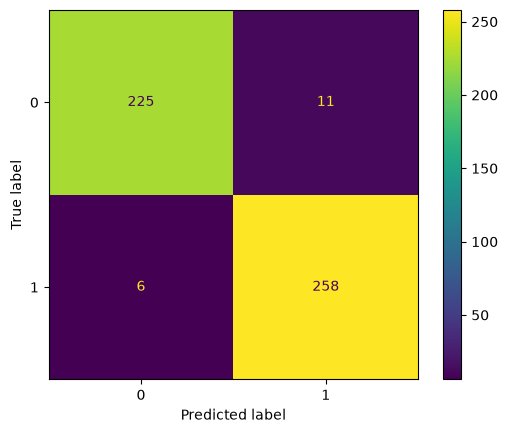

In [10]:
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

print(f"F1 score: {f1_score(y_test, y_test_pred)}")
print(f"Recall: {recall_score(y_test, y_test_pred)}")
print(f"Precision: {precision_score(y_test, y_test_pred)}")
print(classification_report(y_test, y_test_pred, labels=[0, 1]))

cm = confusion_matrix(y_test, y_test_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()

## Model Calibration

In [11]:
import matplotlib.pyplot as plt

from sklearn.frozen import FrozenEstimator
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

CALIBRATION_BINS = 5


def ece(y_true, y_prob, n_bins=CALIBRATION_BINS):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins[1:-1])

    return sum(
        np.mean(bin_ids == i)
        * abs(np.mean(y_true[bin_ids == i]) - np.mean(y_prob[bin_ids == i]))
        for i in range(n_bins)
        if np.any(bin_ids == i)
    )


models = {
    "Uncalibrated": clf,
    "Platt scaling": CalibratedClassifierCV(
        FrozenEstimator(clf),
        method="sigmoid",
    ).fit(X_calib, y_calib),
    "Isotonic regression": CalibratedClassifierCV(
        FrozenEstimator(clf),
        method="isotonic",
    ).fit(X_calib, y_calib),
}

In [12]:
results = {
    name: {
        "proba": model.predict_proba(X_test)[:, 1],
    }
    for name, model in models.items()
}

for name, result in results.items():
    result["ece"] = ece(y_test, result["proba"])
    print(f"{name} ECE: {result['ece']:.4f}")

Uncalibrated ECE: 0.0320
Platt scaling ECE: 0.0217
Isotonic regression ECE: 0.0150


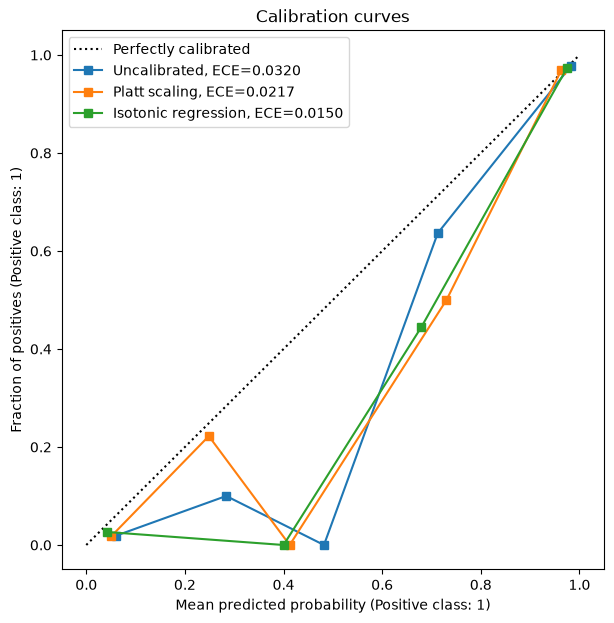

In [13]:
fig, ax = plt.subplots(figsize=(7, 7))

for name, result in results.items():
    CalibrationDisplay.from_predictions(
        y_true=y_test,
        y_prob=result["proba"],
        n_bins=CALIBRATION_BINS,
        strategy="uniform",
        name=f"{name}, ECE={result['ece']:.4f}",
        ax=ax,
    )

ax.set_title("Calibration curves")
ax.legend()
plt.show()

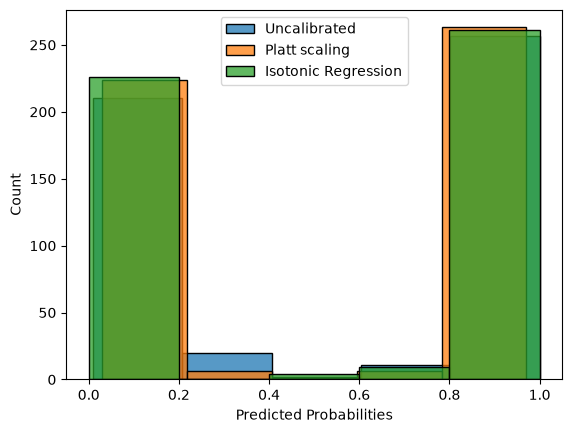

In [27]:
import seaborn as sns


sns.histplot(
    results["Uncalibrated"]["proba"], label="Uncalibrated", bins=CALIBRATION_BINS
)
sns.histplot(
    results["Platt scaling"]["proba"], label="Platt scaling", bins=CALIBRATION_BINS
)
sns.histplot(
    results["Isotonic regression"]["proba"],
    label="Isotonic Regression",
    bins=CALIBRATION_BINS,
)
plt.xlabel("Predicted Probabilities")
plt.legend()

In [37]:
for name, model in models.items():
    y_pred = model.predict(X_test)

    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"{name}")
    print(f"  F1 score:  {f1:.4f}")
    print(f"  Accuracy:  {accuracy:.2%}")

Uncalibrated
  F1 score:  0.9681
  Accuracy:  96.60%
Platt scaling
  F1 score:  0.9699
  Accuracy:  96.80%
Isotonic regression
  F1 score:  0.9609
  Accuracy:  95.80%


## Check features

In [38]:
feature_names = feature_processing_pipeline.named_steps[
    "features"
].get_feature_names_out()

features = pd.DataFrame(
    {
        "feature_name": feature_names,
        "feature_importance": clf.feature_importances_,
    }
).sort_values("feature_importance", ascending=False)

features.query("feature_importance > 0.0")

,feature_name,feature_importance
987,description_tfidf__white,0.080562
1000,manual_features__proportion_of_stopwords,0.050481
906,description_tfidf__size,0.033269
494,named_entities_tfidf__yk,0.031696
835,description_tfidf__pink,0.026945
939,description_tfidf__tag,0.026862
542,description_tfidf__blue,0.024953
806,description_tfidf__nike,0.024629
933,description_tfidf__summer,0.023880
976,description_tfidf__vintage,0.023742


# Summary of identified issues

### 1. Data leakage: [Done]
- train/ test was concatenated, and feature engineering done on all
- then, model was train on all data, and evaluated on test data that was seen during training
- this needs to be fixed, or any evaluation is non realistic
- using sklearn pipelines could make this easier and repeatable to get this into prod: one single pipeline to handle train and test data for inference

### 2. Training issues:
- n_estimator: 2 [done]
- product_id used as features [done]
- non-pythonic way of code: using eval() [done]
- complex/ non-repeatable way of feature engineering -> hard to convert into production code -> use Sklearn pipelines at the very least [done]
- no hyperparam tuning [done]

### 3. Evaluation criteria: [done]
- Accuracy isn't the best metric
- We should care about cost asymmetry for different parties:
    - false positive: bad experience for sellers
    - false negative: bad experience for buyers
    - we should compare F1 score at the minimum, or report on both precision and recall to understand trade off
- Also this could be a ranking problem as we may be in taking risk-based approach to handling spams
    - inspect to make sure probabilities are calibrated, and if not, fix calibration prior to reporting on other metrics

### 4. Feature Engineering issues:
- Stripping out a lot of potentially useful signals of spammy texts, e.g. hashtags, digits, only considering unigrams/ ignoring compound terms
- TFIDF resulting in very sparse matrix
- Only very basic feature engineering. We could do a lot more here:
    - Number of spammy terms captured e.g.
    - Number of brands mentioned in description
    - Number of sizing terms mentioned in description
    - Number of styles mentioned in description
    - Number of terms matching previously known spammy terms
    - Total length of description
    - For something to be considered spammy, we want to know how relevant the words in the description is in relevance to the item
    - So we probably want something along those lines -> does this word relate to the item at all?
- Using SpaCY for NER -> is this good for fashion brand though?
    - Do we need explicit brand dictionary or even a tuned brand specific NER to parse out brand names from descriptions?
- Lower casing, then true casing again -> redundant steps
- `proportion_of_numbers`: doesn't work on terms where digits is in the word e.g. y2k
- removing digits remove legitimate terms e.g. y2k -> could there be a better way at handling this